In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

import os
import json
from datetime import datetime

In [6]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [7]:
df = pd.read_csv('data/S12-hw-dataset.csv')
print("Размер датасета:", df.shape)
df.head()

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
print("Диапазон дат:", df['date'].min(), "–", df['date'].max())
print("Пропуски:\n", df.isnull().sum())

Размер датасета: (4320, 2)
Диапазон дат: 2025-01-01 00:00:00 – 2025-06-29 23:00:00
Пропуски:
 date      0
target    0
dtype: int64


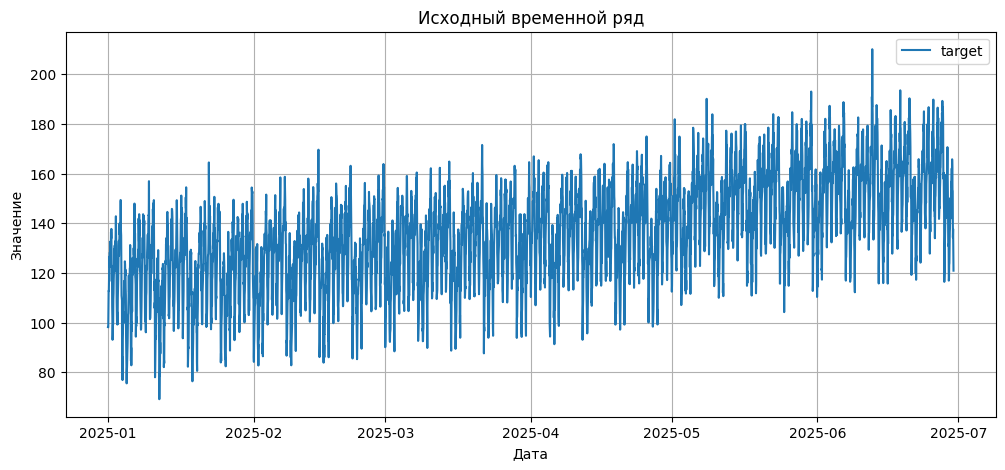

Статистики:
count    4320.000000
mean      135.605840
std        21.384633
min        69.100000
25%       120.537500
50%       135.835000
75%       150.625000
max       210.100000
Name: target, dtype: float64
ряд демонстрирует тренд, возможно сезонность, есть выбросы, нестационарность.


In [8]:
plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['target'], label='target')
plt.title('Исходный временной ряд')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True)
plt.show()

print("Статистики:")
print(df['target'].describe())
print("ряд демонстрирует тренд, возможно сезонность, есть выбросы, нестационарность.")

if df['target'].isnull().any():
    df['target'] = df['target'].interpolate(method='linear')
    print("Пропуски заполнены линейной интерполяцией.")

In [9]:
total = len(df)
train_end = int(total * 0.7)
val_end = int(total * 0.85)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

print(f"Train: {len(train_df)} samples ({train_df['date'].min()} – {train_df['date'].max()})")
print(f"Validation: {len(val_df)} samples ({val_df['date'].min()} – {val_df['date'].max()})")
print(f"Test: {len(test_df)} samples ({test_df['date'].min()} – {test_df['date'].max()})")


Train: 3024 samples (2025-01-01 00:00:00 – 2025-05-06 23:00:00)
Validation: 648 samples (2025-05-07 00:00:00 – 2025-06-02 23:00:00)
Test: 648 samples (2025-06-03 00:00:00 – 2025-06-29 23:00:00)


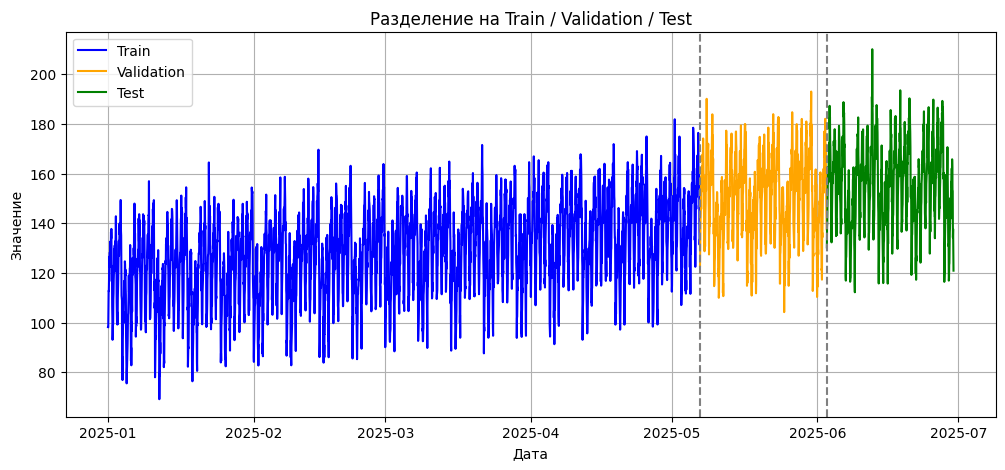

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(train_df['date'], train_df['target'], label='Train', color='blue')
plt.plot(val_df['date'], val_df['target'], label='Validation', color='orange')
plt.plot(test_df['date'], test_df['target'], label='Test', color='green')
plt.axvline(x=train_df['date'].iloc[-1], linestyle='--', color='gray')
plt.axvline(x=val_df['date'].iloc[-1], linestyle='--', color='gray')
plt.title('Разделение на Train / Validation / Test')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True)
plt.savefig('artifacts/figures/series_split.png')
plt.show()

In [11]:
def create_features(df, lag_list=[1,7,14], rolling_windows=[7]):

    data = df.copy()
    for lag in lag_list:
        data[f'lag_{lag}'] = data['target'].shift(lag)
    for w in rolling_windows:
        data[f'rolling_mean_{w}'] = data['target'].rolling(window=w, min_periods=1).mean()
        data[f'rolling_std_{w}'] = data['target'].rolling(window=w, min_periods=1).std()
    data['day_of_week'] = data['date'].dt.dayofweek
    data['month'] = data['date'].dt.month
    data = data.dropna().reset_index(drop=True)
    return data

df_feat = create_features(df)
print("Размер после добавления признаков:", df_feat.shape)

Размер после добавления признаков: (4306, 9)


In [12]:
train_feat = df_feat[df_feat['date'] < train_df['date'].max()].copy()
val_feat = df_feat[(df_feat['date'] >= train_df['date'].max()) & (df_feat['date'] < val_df['date'].max())].copy()
test_feat = df_feat[df_feat['date'] >= val_df['date'].max()].copy()

print(f"Train features: {len(train_feat)}, Val: {len(val_feat)}, Test: {len(test_feat)}")

target_col = 'target'
X_train = train_feat.drop(columns=['date', target_col])
y_train = train_feat[target_col]
X_val = val_feat.drop(columns=['date', target_col])
y_val = val_feat[target_col]
X_test = test_feat.drop(columns=['date', target_col])
y_test = test_feat[target_col]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Train features: 3009, Val: 648, Test: 649


In [13]:
def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return mae, rmse, mape


naive_pred_val = []
prev = y_train.iloc[-1] 
for i in range(len(y_val)):
    naive_pred_val.append(prev)
    prev = y_val.iloc[i] 
naive_pred_val = np.array(naive_pred_val)

mae_naive, rmse_naive, mape_naive = compute_metrics(y_val, naive_pred_val)
print(f"B1 (Naive) on validation: MAE={mae_naive:.4f}, RMSE={rmse_naive:.4f}, MAPE={mape_naive:.2f}%")

B1 (Naive) on validation: MAE=6.4383, RMSE=8.1978, MAPE=4.39%


In [14]:
window_ma = 7
ma_pred_val = []
history = list(y_train.values)
for i in range(len(y_val)):
    if len(history) >= window_ma:
        pred = np.mean(history[-window_ma:])
    else:
        pred = np.mean(history)
    ma_pred_val.append(pred)
    history.append(y_val.iloc[i])

mae_ma, rmse_ma, mape_ma = compute_metrics(y_val, ma_pred_val)
print(f"B2 (Moving Average, window={window_ma}) on validation: MAE={mae_ma:.4f}, RMSE={rmse_ma:.4f}, MAPE={mape_ma:.2f}%")

B2 (Moving Average, window=7) on validation: MAE=12.6936, RMSE=15.2061, MAPE=8.81%


In [15]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

ridge_pred_val = ridge.predict(X_val_scaled)
mae_ridge, rmse_ridge, mape_ridge = compute_metrics(y_val, ridge_pred_val)
print(f"B3 (Ridge) on validation: MAE={mae_ridge:.4f}, RMSE={rmse_ridge:.4f}, MAPE={mape_ridge:.2f}%")

B3 (Ridge) on validation: MAE=6.0561, RMSE=7.5299, MAPE=4.02%


In [16]:
window_size = 7
horizon = 1  

target_scaler = StandardScaler()
target_scaler.fit(train_df[['target']])

def create_sequences(data, window_size, horizon=1):
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size+horizon-1])  
    return np.array(X), np.array(y)

train_vals = target_scaler.transform(train_df[['target']]).flatten()
val_vals = target_scaler.transform(val_df[['target']]).flatten()
test_vals = target_scaler.transform(test_df[['target']]).flatten()

X_train_seq, y_train_seq = create_sequences(train_vals, window_size, horizon)
X_val_seq, y_val_seq = create_sequences(val_vals, window_size, horizon)
X_test_seq, y_test_seq = create_sequences(test_vals, window_size, horizon)

print(f"Train sequences: {X_train_seq.shape}")
print(f"Val sequences: {X_val_seq.shape}")
print(f"Test sequences: {X_test_seq.shape}")

Train sequences: (3017, 7)
Val sequences: (641, 7)
Test sequences: (641, 7)


In [17]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 32
train_dataset = TimeSeriesDataset(X_train_seq, y_train_seq)
val_dataset = TimeSeriesDataset(X_val_seq, y_val_seq)
test_dataset = TimeSeriesDataset(X_test_seq, y_test_seq)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [18]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.gru(x)  # out: (batch, seq_len, hidden_size)
        out = out[:, -1, :] 
        out = self.fc(out)
        return out.squeeze(-1)

model = GRUModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(X_batch)
    return total_loss / len(loader.dataset)

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            total_loss += loss.item() * len(X_batch)
            all_preds.append(pred.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    mae = mean_absolute_error(all_targets, all_preds)
    rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    mape = mean_absolute_percentage_error(all_targets, all_preds) * 100
    return total_loss / len(loader.dataset), mae, rmse, mape


In [19]:
num_epochs = 50
best_val_loss = float('inf')
best_epoch = 0
train_losses = []
val_losses = []
val_maes = []

for epoch in range(1, num_epochs+1):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_mae, val_rmse, val_mape = evaluate(model, val_loader, criterion, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_maes.append(val_mae)
    
    scheduler.step(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        torch.save(model.state_dict(), 'artifacts/best_gru.pt')
        config = {
            'input_size': 1,
            'hidden_size': 64,
            'num_layers': 2,
            'dropout': 0.2,
            'window_size': window_size,
            'horizon': horizon,
            'batch_size': batch_size,
            'lr': 0.001,
            'seed': SEED,
            'scaler_mean': target_scaler.mean_[0],
            'scaler_scale': target_scaler.scale_[0]
        }
        with open('artifacts/best_gru_config.json', 'w') as f:
            json.dump(config, f, indent=4)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, val_MAE={val_mae:.4f}")

print(f"Best model at epoch {best_epoch} with val_loss={best_val_loss:.4f}")

Epoch 10: train_loss=0.1491, val_loss=0.2102, val_MAE=0.3701
Epoch 20: train_loss=0.1439, val_loss=0.2160, val_MAE=0.3775
Epoch 30: train_loss=0.1431, val_loss=0.2209, val_MAE=0.3830
Epoch 40: train_loss=0.1414, val_loss=0.2142, val_MAE=0.3763
Epoch 50: train_loss=0.1415, val_loss=0.2129, val_MAE=0.3750
Best model at epoch 2 with val_loss=0.1863


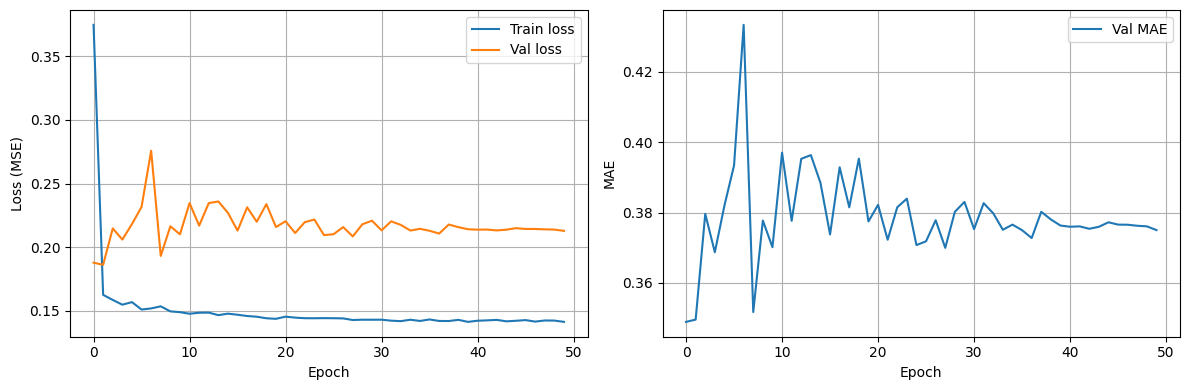

In [20]:
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.subplot(1,2,2)
plt.plot(val_maes, label='Val MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png')
plt.show()

In [21]:
model.load_state_dict(torch.load('artifacts/best_gru.pt'))
val_loss, val_mae_gru, val_rmse_gru, val_mape_gru = evaluate(model, val_loader, criterion, device)
print(f"GRU on validation: MAE={val_mae_gru:.4f}, RMSE={val_rmse_gru:.4f}, MAPE={val_mape_gru:.2f}%")

results = pd.DataFrame({
    'Model': ['Naive', 'Moving Average', 'Ridge', 'GRU'],
    'MAE': [mae_naive, mae_ma, mae_ridge, val_mae_gru],
    'RMSE': [rmse_naive, rmse_ma, rmse_ridge, val_rmse_gru],
    'MAPE': [mape_naive, mape_ma, mape_ridge, val_mape_gru]
})
print(results)

GRU on validation: MAE=0.3496, RMSE=0.4316, MAPE=134.44%
            Model        MAE       RMSE        MAPE
0           Naive   6.438349   8.197825    4.393292
1  Moving Average  12.693552  15.206150    8.811359
2           Ridge   6.056135   7.529930    4.024267
3             GRU   0.349575   0.431593  134.437346


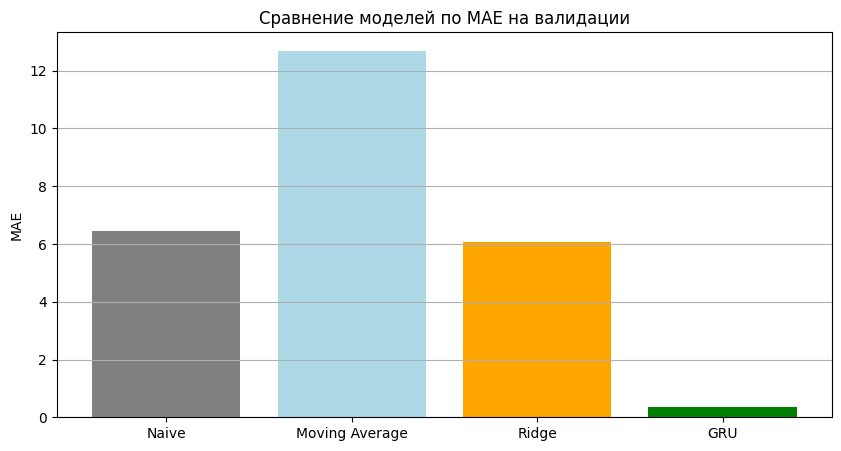

Лучшая модель на валидации: GRU с MAE=0.3496
GRU on test: MAE=0.3601, RMSE=0.4526, MAPE=58.73%


In [22]:
plt.figure(figsize=(10,5))
models = results['Model']
mae_vals = results['MAE']
plt.bar(models, mae_vals, color=['gray', 'lightblue', 'orange', 'green'])
plt.title('Сравнение моделей по MAE на валидации')
plt.ylabel('MAE')
plt.grid(axis='y')
plt.savefig('artifacts/figures/baselines_compare.png')
plt.show()

best_model_name = 'GRU'
print(f"Лучшая модель на валидации: {best_model_name} с MAE={val_mae_gru:.4f}")
test_loss, test_mae_gru, test_rmse_gru, test_mape_gru = evaluate(model, test_loader, criterion, device)
print(f"GRU on test: MAE={test_mae_gru:.4f}, RMSE={test_rmse_gru:.4f}, MAPE={test_mape_gru:.2f}%")

In [23]:
model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        pred = model(X_batch).cpu().numpy()
        all_preds.extend(pred)
        all_targets.extend(y_batch.numpy())
all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

all_preds_orig = target_scaler.inverse_transform(all_preds.reshape(-1,1)).flatten()
all_targets_orig = target_scaler.inverse_transform(all_targets.reshape(-1,1)).flatten()

test_dates = test_df['date'].iloc[window_size+horizon-1:].reset_index(drop=True)

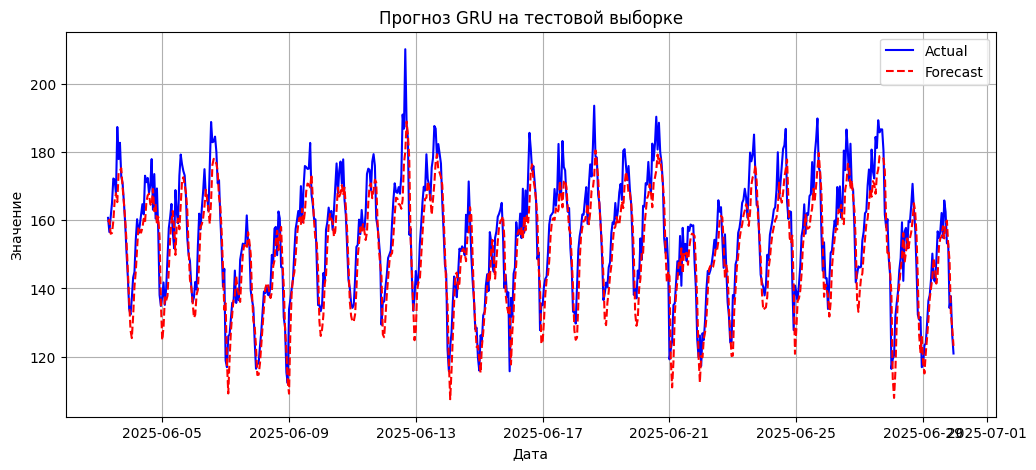

In [24]:
plt.figure(figsize=(12,5))
plt.plot(test_dates, all_targets_orig, label='Actual', color='blue')
plt.plot(test_dates, all_preds_orig, label='Forecast', color='red', linestyle='--')
plt.title('Прогноз GRU на тестовой выборке')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True)
plt.savefig('artifacts/figures/best_forecast_test.png')
plt.show()

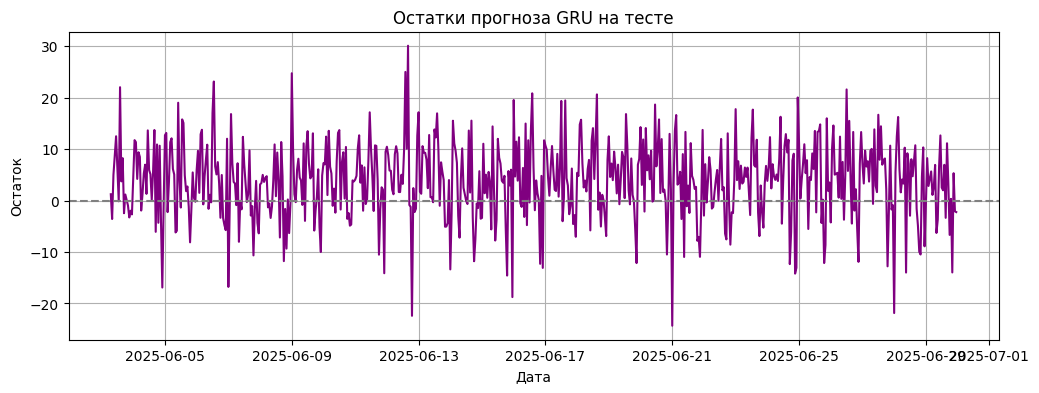

In [25]:
residuals = all_targets_orig - all_preds_orig
plt.figure(figsize=(12,4))
plt.plot(test_dates, residuals, color='purple')
plt.axhline(y=0, linestyle='--', color='gray')
plt.title('Остатки прогноза GRU на тесте')
plt.xlabel('Дата')
plt.ylabel('Остаток')
plt.grid(True)
plt.savefig('artifacts/figures/residuals_best.png')
plt.show()

In [26]:
runs = pd.DataFrame(columns=[
    'experiment_id', 'task', 'dataset', 'seed', 'split_summary', 'window_size', 'horizon',
    'model_summary', 'features_summary', 'scaler', 'optimizer', 'lr', 'epochs_trained',
    'best_val_mae', 'best_val_rmse', 'best_val_mape', 'test_mae', 'test_rmse', 'test_mape', 'notes'
])

runs = pd.concat([runs, pd.DataFrame([{
    'experiment_id': 'B1', 'task': 'forecasting', 'dataset': 'S12-hw-dataset', 'seed': SEED,
    'split_summary': '70/15/15 temporal', 'window_size': None, 'horizon': 1,
    'model_summary': 'Naive (last value)', 'features_summary': 'none',
    'scaler': 'none', 'optimizer': None, 'lr': None, 'epochs_trained': None,
    'best_val_mae': mae_naive, 'best_val_rmse': rmse_naive, 'best_val_mape': mape_naive,
    'test_mae': None, 'test_rmse': None, 'test_mape': None,
    'notes': 'validation only'
}])], ignore_index=True)

runs = pd.concat([runs, pd.DataFrame([{
    'experiment_id': 'B2', 'task': 'forecasting', 'dataset': 'S12-hw-dataset', 'seed': SEED,
    'split_summary': '70/15/15 temporal', 'window_size': window_ma, 'horizon': 1,
    'model_summary': 'Moving Average', 'features_summary': 'rolling mean window 7',
    'scaler': 'none', 'optimizer': None, 'lr': None, 'epochs_trained': None,
    'best_val_mae': mae_ma, 'best_val_rmse': rmse_ma, 'best_val_mape': mape_ma,
    'test_mae': None, 'test_rmse': None, 'test_mape': None,
    'notes': 'validation only'
}])], ignore_index=True)

runs = pd.concat([runs, pd.DataFrame([{
    'experiment_id': 'B3', 'task': 'forecasting', 'dataset': 'S12-hw-dataset', 'seed': SEED,
    'split_summary': '70/15/15 temporal', 'window_size': None, 'horizon': 1,
    'model_summary': 'Ridge regression', 'features_summary': 'lags, rolling stats, calendar',
    'scaler': 'StandardScaler', 'optimizer': None, 'lr': None, 'epochs_trained': None,
    'best_val_mae': mae_ridge, 'best_val_rmse': rmse_ridge, 'best_val_mape': mape_ridge,
    'test_mae': None, 'test_rmse': None, 'test_mape': None,
    'notes': 'validation only'
}])], ignore_index=True)

runs = pd.concat([runs, pd.DataFrame([{
    'experiment_id': 'R1', 'task': 'forecasting', 'dataset': 'S12-hw-dataset', 'seed': SEED,
    'split_summary': '70/15/15 temporal', 'window_size': window_size, 'horizon': horizon,
    'model_summary': 'GRU (2 layers, hidden 64)', 'features_summary': 'only target',
    'scaler': 'StandardScaler (target only)', 'optimizer': 'Adam', 'lr': 0.001, 'epochs_trained': best_epoch,
    'best_val_mae': val_mae_gru, 'best_val_rmse': val_rmse_gru, 'best_val_mape': val_mape_gru,
    'test_mae': test_mae_gru, 'test_rmse': test_rmse_gru, 'test_mape': test_mape_gru,
    'notes': 'best model'
}])], ignore_index=True)

runs.to_csv('artifacts/runs.csv', index=False)